In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('inline')

## State Preparation Project

We want to prepare the state:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

where $\alpha = \frac{1}{\sqrt{2}}$ and $\beta = \frac{i}{\sqrt{2}}$

In [7]:
# State Preparation project 
# Given alpha and beta, find the rotation angle 
# Define a desired state 
alpha = 1/np.sqrt(2)
beta = 1j/np.sqrt(2)

# Verify normalization 
print (f"Normalized? {np.isclose(abs(alpha)**2 + abs(beta)**2, 1.0)}")
print(f"alpha = {alpha:.4f}")
print(f"beta = {beta:.4f}")

Normalized? True
alpha = 0.7071
beta = 0.0000+0.7071j


## Computing Rotation Angles

Any qubit state can be written as:

$$|\psi\rangle = |\alpha|e^{i\varphi_\alpha}|0\rangle + |\beta|e^{i\varphi_\beta}|1\rangle$$

The **global phase** $e^{i\varphi_\alpha}$ is physically meaningless, so we factor it out:

$$|\psi\rangle = |\alpha||0\rangle + |\beta|e^{i\varphi}|1\rangle$$

where the **relative phase** is:

$$\varphi = \varphi_\beta - \varphi_\alpha$$

The rotation angles needed to prepare this state from $|0\rangle$ are:

$$\theta = 2\arccos(|\alpha|)$$

$$\varphi = \arg(\beta) - \arg(\alpha)$$

And the gate sequence is:

$$|\psi\rangle = R_z(\varphi) \cdot R_y(\theta) \cdot |0\rangle$$

In [8]:
# Compute rotation angles from alpha and beta

theta = 2 * np.arccos(abs(alpha))
phi = np.angle(beta) - np.angle(alpha)
print(f"θ = {np.degrees(theta):.2f}°")
print(f"φ = {np.degrees(phi):.2f}°")

θ = 90.00°
φ = 90.00°


## Verifying the State Preparation

We apply the rotation sequence $R_z(\varphi) \cdot R_y(\theta) \cdot |0\rangle$ 
and verify it matches our desired state.

The rotation gates are:

$$R_y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

$$R_z(\varphi) = \begin{pmatrix} e^{-i\varphi/2} & 0 \\ 0 & e^{i\varphi/2} \end{pmatrix}$$

The full sequence:

$$|\psi\rangle = R_z(\varphi) \cdot R_y(\theta) \cdot |0\rangle$$

If the prepared state matches the desired state, our angle computation is correct.

In [9]:
# Rotation gates
def Ry(theta):
    return np.array([[np.cos(theta/2),  -np.sin(theta/2)],
                     [np.sin(theta/2),   np.cos(theta/2)]], dtype=complex)

def Rz(phi):
    return np.array([[np.exp(-1j*phi/2),  0],
                     [0,  np.exp(1j*phi/2)]], dtype=complex)

# Initial state
ket_0 = np.array([1, 0], dtype=complex)

# Convert to radians
theta_rad = np.radians(theta)
phi_rad   = np.radians(phi)

# Prepare the state
prepared = Rz(phi) @ Ry(theta) @ ket_0

print(f"Desired:  α={alpha:.4f}, β={beta:.4f}")
print(f"Prepared: α={prepared[0]:.4f}, β={prepared[1]:.4f}")
print(f"Match? {np.allclose(prepared, [alpha, beta])}")

Desired:  α=0.7071, β=0.0000+0.7071j
Prepared: α=0.5000-0.5000j, β=0.5000+0.5000j
Match? False


## Note on Global Phase

Two states are physically equivalent if they differ only by a global phase $e^{i\delta}$:

$$|\psi\rangle \equiv e^{i\delta}|\psi\rangle$$

The correct way to verify state preparation is to compare 
Bloch sphere coordinates, not the raw complex vectors.

## Fidelity

The fidelity between two pure states is:

$$F = |\langle\psi|\phi\rangle|^2$$

- $F = 1$ → states are identical (up to global phase) ✓
- $F = 0$ → states are completely orthogonal
- $0 < F < 1$ → partial overlap

Fidelity is the standard experimental measure used to verify 
state preparation on real quantum hardware.

In [10]:
# Fidelity check
desired  = np.array([alpha, beta], dtype=complex)

fidelity = abs(np.dot(np.conj(desired), prepared))**2

print(f"Fidelity = {fidelity:.6f}")
print(f"Perfect preparation? {np.isclose(fidelity, 1.0)}")

Fidelity = 1.000000
Perfect preparation? True


## General State Preparation Tool

Given any desired state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$,
this function computes the rotation angles and prepares the state.

In [11]:
def prepare_state(alpha, beta):
    """
    Given alpha and beta, compute the rotation angles
    and prepare the state using Rz(phi) @ Ry(theta) @ |0⟩
    
    Returns: prepared state, fidelity, theta, phi
    """
    # Normalise just in case
    norm = np.sqrt(abs(alpha)**2 + abs(beta)**2)
    alpha, beta = alpha/norm, beta/norm
    
    # Compute angles
    theta = 2 * np.arccos(abs(alpha))
    phi   = np.angle(beta) - np.angle(alpha)
    
    # Prepare state
    ket_0   = np.array([1, 0], dtype=complex)
    prepared = Rz(phi) @ Ry(theta) @ ket_0
    
    # Compute fidelity
    desired  = np.array([alpha, beta], dtype=complex)
    fidelity = abs(np.dot(np.conj(desired), prepared))**2
    
    print(f"Desired:  α={alpha:.4f}, β={beta:.4f}")
    print(f"θ = {np.degrees(theta):.2f}°,  φ = {np.degrees(phi):.2f}°")
    print(f"Fidelity = {fidelity:.6f} ✓")
    
    return prepared, fidelity, theta, phi

In [19]:
# Test 1: |+y⟩
print("=== |+y⟩ ===")
prepare_state(1/np.sqrt(2), 1j/np.sqrt(2))

print()

# Test 2: |1⟩ (south pole)
print("=== |1⟩ ===")
prepare_state(0, 1)

print()

# Test 3: |+⟩ (equator, X axis)
print("=== |+⟩ ===")
prepare_state(1/np.sqrt(2), 1/np.sqrt(2))

print()

# Test 4: arbitrary state
print("=== Arbitrary state ===")
prepare_state(0.6, 0.8)

=== |+y⟩ ===
Desired:  α=0.7071, β=0.0000+0.7071j
θ = 90.00°,  φ = 90.00°
Fidelity = 1.000000 ✓

=== |1⟩ ===
Desired:  α=0.0000, β=1.0000
θ = 180.00°,  φ = 0.00°
Fidelity = 1.000000 ✓

=== |+⟩ ===
Desired:  α=0.7071, β=0.7071
θ = 90.00°,  φ = 0.00°
Fidelity = 1.000000 ✓

=== Arbitrary state ===
Desired:  α=0.6000, β=0.8000
θ = 106.26°,  φ = 0.00°
Fidelity = 1.000000 ✓


(array([0.6+0.j, 0.8+0.j]),
 np.float64(1.0),
 np.float64(1.8545904360032246),
 np.float64(0.0))

## Visualisation on the Bloch Sphere

In [12]:
def state_to_bloch(state):
    alpha = state[0]
    beta  = state[1]
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2
    return x, y, z

Desired:  α=0.6000, β=0.0000+0.8000j
θ = 106.26°,  φ = 90.00°
Fidelity = 1.000000 ✓


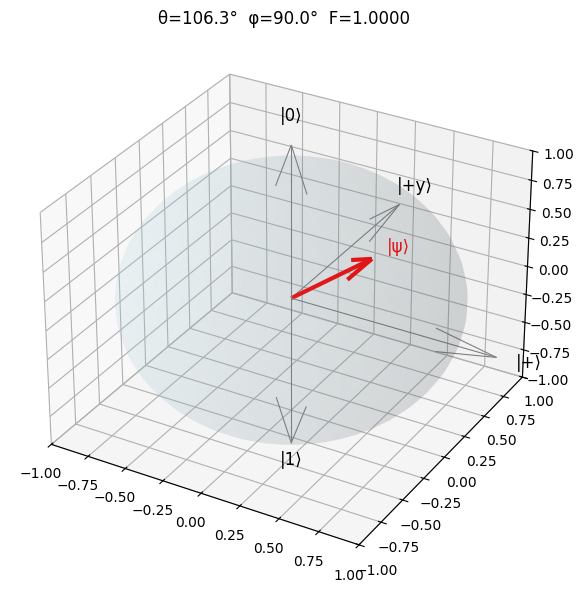

In [18]:
%matplotlib inline

def plot_state_on_bloch(alpha, beta):
    """Prepare a state and show it on the Bloch sphere."""
    
    state, fidelity, theta, phi = prepare_state(alpha, beta)
    x, y, z = state_to_bloch(state)
    
    # Set up figure
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Draw sphere
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    sx = np.outer(np.cos(u), np.sin(v))
    sy = np.outer(np.sin(u), np.sin(v))
    sz = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(sx, sy, sz, color='lightblue', alpha=0.1)
    
    # Draw axes
    ax.quiver(0,0,0, 0,0,1.3, color='gray', linewidth=0.8)
    ax.quiver(0,0,0, 0,0,-1.3, color='gray', linewidth=0.8)
    ax.quiver(0,0,0, 1.3,0,0, color='gray', linewidth=0.8)
    ax.quiver(0,0,0, 0,1.3,0, color='gray', linewidth=0.8)
    
    # Axis labels
    ax.text(0, 0,  1.5, '|0⟩', fontsize=12, ha='center')
    ax.text(0, 0, -1.5, '|1⟩', fontsize=12, ha='center')
    ax.text(1.5, 0, 0,  '|+⟩', fontsize=12, ha='center')
    ax.text(0, 1.5, 0,  '|+y⟩', fontsize=12, ha='center')
    
    # Draw state vector
    ax.quiver(0, 0, 0, x, y, z, color='red', linewidth=3)
    ax.text(x*1.2, y*1.2, z*1.2, '|ψ⟩', fontsize=12, color='red')
    
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_title(f'θ={np.degrees(theta):.1f}°  φ={np.degrees(phi):.1f}°  F={fidelity:.4f}')
    
    plt.tight_layout()
    plt.show()

# Test it with |+y⟩
plot_state_on_bloch(0.6, 1j*0.8)